# Startup
Run these cells to initialize the notebook and make contact with your measuring instruments

In [1]:
import pyvisa as visa
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import scipy
import os
import sys
rm = visa.ResourceManager()
print(rm.list_resources())

ModuleNotFoundError: No module named 'pyvisa'

In [2]:
'''
Use the output from the above cell to rename the resources as necessary. The query commands ensure the keithleys
are online and listening
'''

Keithley = rm.open_resource('GPIB0::20::INSTR')
Keithleygate = rm.open_resource('GPIB0::25::INSTR')
print(Keithley.query('*IDN?'))
print(Keithleygate.query('*IDN?'))

KEITHLEY INSTRUMENTS INC.,MODEL 2400,1340110,C32   Oct  4 2010 14:20:11/A02  /R/J

KEITHLEY INSTRUMENTS INC.,MODEL 2400,1197267,C33   Mar 31 2015 09:32:39/A02  /K/J



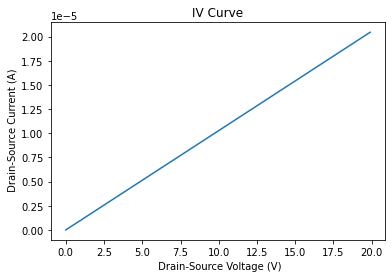

In [5]:
'''
here is an example of how to use the attached scripts.
First, make sure that they are in the same folder as this notebook
Then, run the following command with the name of the script along with inputs for operation
In this case they are: 
    start voltage, stop voltage, step voltage, data file name, instrument to use (source or gate),direction

This specific script does not save the file, the others do though and they save right to 
the data folder that is in the parent directory to this one
'''
%run KeithleyIVSweep.py 0 20 0.1 test.txt GPIB0::20::INSTR up

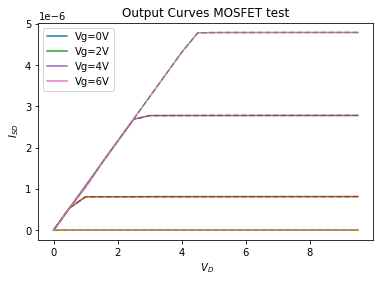

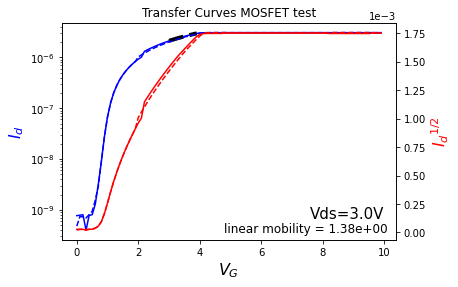

In [6]:
'''
This cell is used to test that your setup is accurate.
It runs output and transfer curves for the testing fixture with a mosfet

Connect everything normally, but when you connect to the mosfet fixture, 
connect the drain probe to the source pin and the source probe to the 
drain pin, the gate can be connected as normal. What you should see is 
very clean output curves and transfer curves with a mobility of 1.37 
(thia mobility is not real)
'''
%run mosfet_test.py GPIB0::25::INSTR GPIB0::20::INSTR

# Output Curves
The following measures the source-drain current as the source-drain voltage sweeps at constant gate voltage. These are called output curves and are a good indication that a transistor works. It can also give you an idea of the drain voltage to pick when measuring transfer curves for mobility

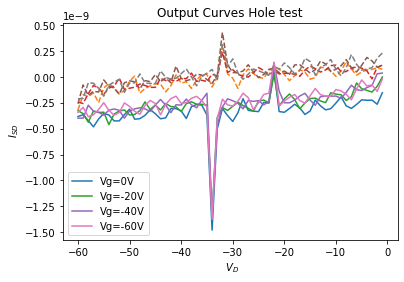

In [3]:
%run output_curves.py test hole GPIB0::25::INSTR GPIB0::20::INSTR

# Transfer Curves
The following runs the transfer curves for a transistor by measuring the drain-source current and sweeping the drain-gate voltage and maintaing a constant source-drain voltage. From these results, you can extract charge carrier mobility.

could not find linear region


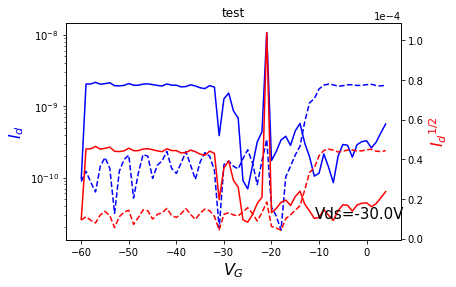

In [4]:
# these transfer curves run quickly because they have only a 10ms source-delay
# this should help with noise but doesnt completely eliminate it, use the smoothing script for that
%run transfer_curves.py -30 test hole GPIB0::25::INSTR GPIB0::20::INSTR

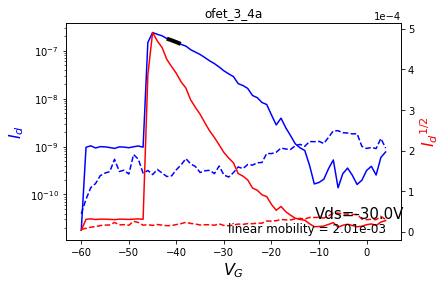

could not find linear region


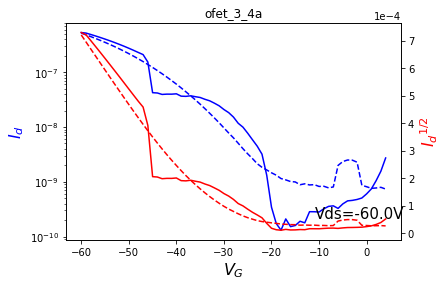

In [22]:
# these take a long time because they are running a fixed average smoothing function
# but my god do they give you smooth data
%run transfer_curves_smoothing.py -30 ofet_3_4a hole GPIB0::25::INSTR GPIB0::20::INSTR
%run transfer_curves_smoothing.py -60 ofet_3_4a hole GPIB0::25::INSTR GPIB0::20::INSTR

# Analysis
The following cells help with a quick analysis of the data that you just got

In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
import scipy
import ofet_functions as ofef

In [2]:
# use this cell to see all the data in a folder
data_directory = '/Users/lorenzoguio/Documents/2024-03-28_idtbt_in_varying_solvents/data/'

# make a dictionary to hold the raw data 
ofet_data = {}
for filename in os.listdir(data_directory):
    if 'transfer_curve' in filename:
        dataname = filename.split('.')[0]
        print(dataname)
        ofet_data[dataname] = pd.read_csv(data_directory + filename, sep = '\t')
        vg = ofet_data[dataname].loc[:,'vg']
        id_up = np.absolute(ofet_data[dataname].loc[:,'id_up'])
        id_down = np.absolute(ofet_data[dataname].loc[:,'id_down'])
        vd = ofet_data[dataname].loc[:,'vd'][0]
        ofef.transfer_curve_plot(vg,[id_down,id_up],vd,None,dataname)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lorenzoguio/Documents/2024-03-28_idtbt_in_varying_solvents/data/'

In [10]:
''' this cell exists to initialize a dictionary that contains results '''
ofet_results = {}

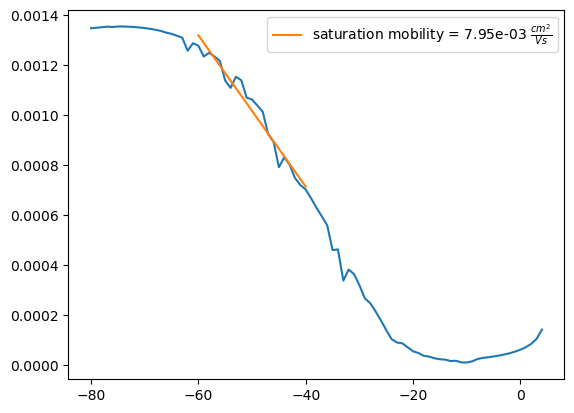

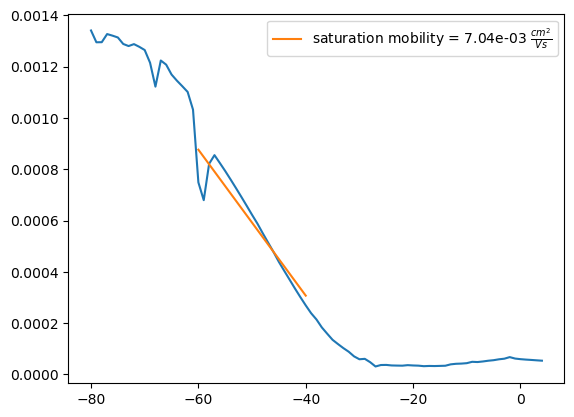

In [62]:
'''
This cell can be used to determine saturation mobility from the above curves
The first part requires some input
'''

# input here the filename of the data you want to analyze
filename = 'transfer_curve_solvent_1_1_4'

# input here parameters to calculate the mobility
L = 50        #50 micron channel length
W = 1000      #1000 micron channel width
Ci = 11.5e-9    #10 nF/cm^2 equation: permitivity of dielectric(sio2)*oxide layer thickness in cm (300nm)

# input here the gate voltage of the ROI for saturation mobility
roi = [-60,-40]

''' this is the analysis bit '''

# load data from saved file name
id_type = 'id_down'
vg,id = ofet_data[filename].loc[:,'vg'], np.absolute(ofet_data[filename].loc[:,id_type])

# pulling the data in the ROI
roi.sort()
vg_roi = vg[(roi[0] <= vg) & (vg <= roi[1])]
id_roi = id[(roi[0] <= vg) & (vg <= roi[1])]

# actually run a linear regression to draw a slope out from the ROI
mu_sat_down,yregress = ofef.saturation_mobility(L,W,Ci,vg_roi,id_roi)
mobility_label = "saturation mobility = " + str(mu_sat_down) + r' $\frac{cm^2}{Vs}$'
plt.figure()
sqrt_id = np.sqrt(id.to_numpy())
plt.plot(vg,sqrt_id)
plt.plot(vg_roi,yregress,label = mobility_label)
plt.yscale('linear')
plt.legend()
plt.show()

# load data from saved file name
id_type = 'id_up'
vg,id = ofet_data[filename].loc[:,'vg'], np.absolute(ofet_data[filename].loc[:,id_type])

# pulling the data in the ROI
roi.sort()
vg_roi = vg[(roi[0] <= vg) & (vg <= roi[1])]
id_roi = id[(roi[0] <= vg) & (vg <= roi[1])]

# actually run a linear regression to draw a slope out from the ROI
mu_sat_up,yregress = ofef.saturation_mobility(L,W,Ci,vg_roi,id_roi)
mobility_label = "saturation mobility = " + str(mu_sat_up) + r' $\frac{cm^2}{Vs}$'
plt.figure()
sqrt_id = np.sqrt(id.to_numpy())
plt.plot(vg,sqrt_id)
plt.plot(vg_roi,yregress,label = mobility_label)
plt.yscale('linear')
plt.legend()
plt.show()

# save the higher value to the list of lists
if float(mu_sat_up) > float(mu_sat_down):
    best_result = mu_sat_up 
else:
    best_result = mu_sat_down
ofet_results[filename] = best_result

In [63]:
ofet_results

{'transfer_curve_solvent_2_1_2': '1.42e-02',
 'transfer_curve_solvent_1_2_1': '7.28e-03',
 'transfer_curve_solvent_1_1_1': '1.04e-02',
 'transfer_curve_solvent_2_1_1': '1.5e-02',
 'transfer_curve_solvent_3_1_1': '4.4e-03',
 'transfer_curve_solvent_1_2_2': '7.96e-03',
 'transfer_curve_solvent_1_2_4': '7.83e-03',
 'transfer_curve_solvent_1_2_3': '8.48e-03',
 'transfer_curve_solvent_3_1_3': '6.19e-03',
 'transfer_curve_solvent_1_1_2': '5.38e-04',
 'transfer_curve_solvent_1_1_5': '1.18e-02',
 'transfer_curve_solvent_2_1_3': '2.75e-04',
 'transfer_curve_solvent_3_1_2': '1.09e-02',
 'transfer_curve_solvent_1_1_4': '7.95e-03'}

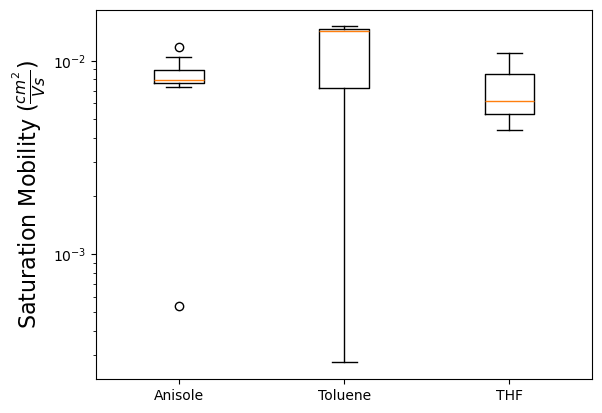

In [76]:
# this will create box plots, make sure you used a dictionary from before
samples = [1,2,3]
labels = ['Anisole','Toluene','THF']
sample_results = []
for i in samples:
    current_sample_result = []
    for sample in ofet_results.keys():
        current_sample = int(sample.split('_')[3])
        if i == current_sample:
            current_sample_result.append(float(ofet_results[sample]))
    sample_results.append(current_sample_result)

plt.boxplot(sample_results, labels = labels)
plt.ylabel('Saturation Mobility ' + r'$(\frac{cm^2}{Vs})$', fontsize = 16)
plt.yscale('log')
plt.show()

In [19]:
'''
This cell can be used to determine linear mobility from the above curves
The first part requires some input
'''

# input here the filename of the data you want to analyze
filename = 'transfer_curve_ofet_3_4a_1'

#input here whether you want to use the up or the down curve
up_or_down = 'up'

# input here parameters to calculate the mobility
L = 50        #50 micron channel length
W = 1000      #1000 micron channel width
Ci = 11.5e-9    #10 nF/cm^2 equation: permitivity of dielectric(sio2)*oxide layer thickness in cm (300nm)

# input here the gate voltage of the ROI for linear mobility
roi = [-50,-55]

''' this is the analysis bit '''

# load data from saved file name
if up_or_down == 'up':
    id_type = 'id_up'
else:
    id_type = 'id_down'
vg,id = ofet_data[filename].loc[:,'vg'], np.absolute(ofet_data[filename].loc[:,id_type])
vd = ofet_data[dataname].loc[:,'vd'][0]

# pulling the data in the ROI
roi.sort()
vg_roi = vg[(roi[0] <= vg) & (vg <= roi[1])]
id_roi = id[(roi[0] <= vg) & (vg <= roi[1])]

# actually run a linear regression to draw a slope out from the ROI
mu_lin,yregress = ofef.linear_mobility(L,W,vd,Ci,vg_roi,id_roi)
mobility_label = "linear mobility = " + str(mu_lin) + r' $\frac{cm^2}{Vs}$'
plt.figure()
plt.plot(vg,id)
plt.plot(vg_roi,yregress,label = mobility_label)
plt.yscale('linear')
plt.legend()
plt.show()

KeyError: 'transfer_curve_ofet_3_4a_1'